In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

os.makedirs('results', exist_ok=True)

In [ ]:
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")
wine_path = os.path.join(path, "WineQT.csv")
wine_df = pd.read_csv(wine_path)

# transformação da variável alvo em binária
# nota >= 7: alta qualidade (1) | Nota < 7: baixa/média qualidade (0)
wine_df['quality_binary'] = wine_df['quality'].apply(lambda x: 1 if x >= 7 else 0)

print("--- Primeiras Linhas do dataset ---")
print(wine_df.head())

print("\n--- Resumo estatístico ---")
print(wine_df.describe())

Using Colab cache for faster access to the 'wine-quality-dataset' dataset.
--- Primeiras Linhas do dataset ---
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9


--- Proporção das Classes de Qualidade (%) ---
quality_binary
0    86.089239
1    13.910761
Name: proportion, dtype: float64


/tmp/ipykernel_11045/520086371.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality_binary', data=wine_df, palette='viridis')


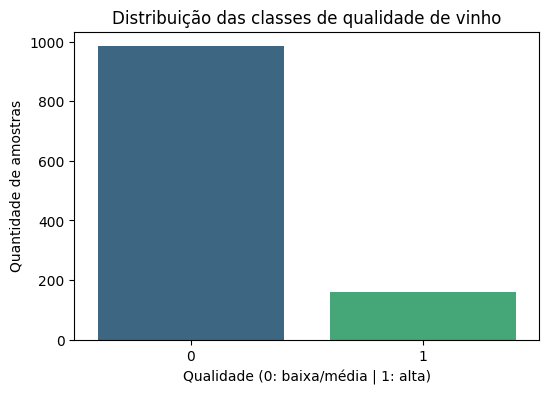

In [ ]:
# ==========================================
# 2. Análise exploratória de dados (EDA)
# ==========================================

# 2.1 balanceamento da variável alvo
print("\n--- Proporção das Classes de Qualidade (%) ---")
print(wine_df['quality_binary'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='quality_binary', data=wine_df, palette='viridis')
plt.title('Distribuição das classes de qualidade de vinho')
plt.xlabel('Qualidade (0: baixa/média | 1: alta)')
plt.ylabel('Quantidade de amostras')
plt.savefig('results/balanceamento_classes.png', bbox_inches='tight')
plt.show()

### Análise do balanceamento de classes
Conforme observado na proporção acima, o conjunto de dados apresenta um forte desbalanceamento: aproximadamente **86%** das amostras pertencem à classe de vinhos de qualidade Baixa/Média (notas < 7) e apenas cerca de 14% representam vinhos de Alta Qualidade (notas >= 7).

**Implicação para a modelagem:**
Esse cenário de desbalanceamento severo impõe um desafio aos modelos de Machine Learning, que tendem a se inclinar a favor da classe majoritária, resultando em falsos negativos para a classe de interesse (vinhos de Alta Qualidade). Para mitigar esse comportamento e garantir que o modelo aprenda a identificar corretamente os vinhos excelentes, utilizaremos a estratégia de pesos balanceados (`class_weight='balanced'`) nas próximas etapas de modelagem.

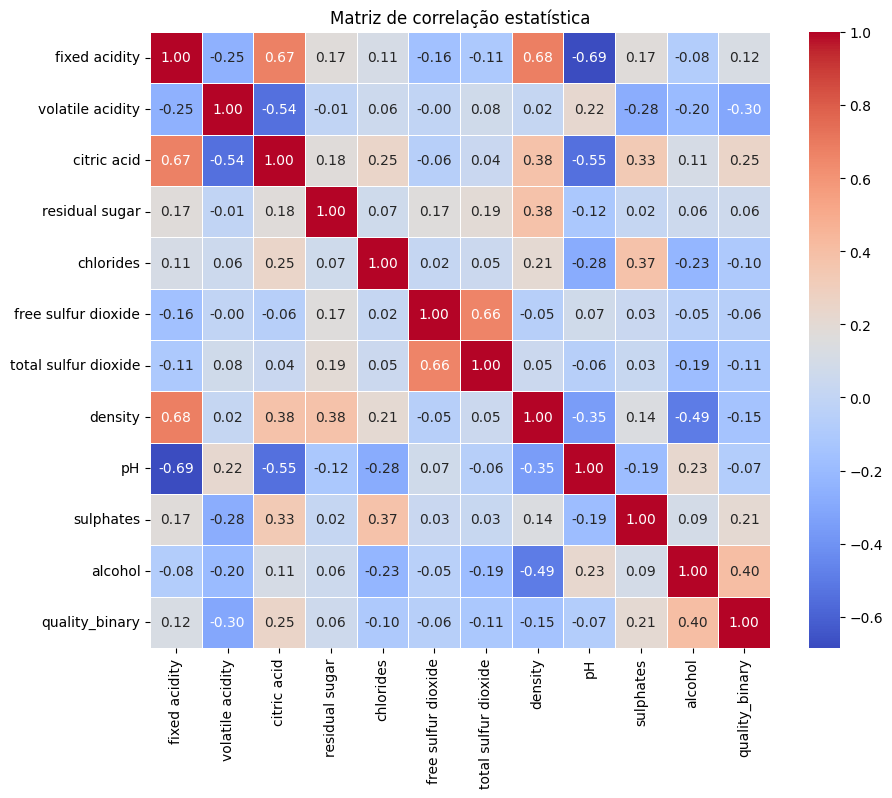

In [ ]:
# 2.2 matriz de correlação
plt.figure(figsize=(10, 8))
corr_matrix = wine_df.drop(['Id', 'quality'], axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlação estatística')
plt.savefig('results/matriz_correlacao.png', bbox_inches='tight')
plt.show()

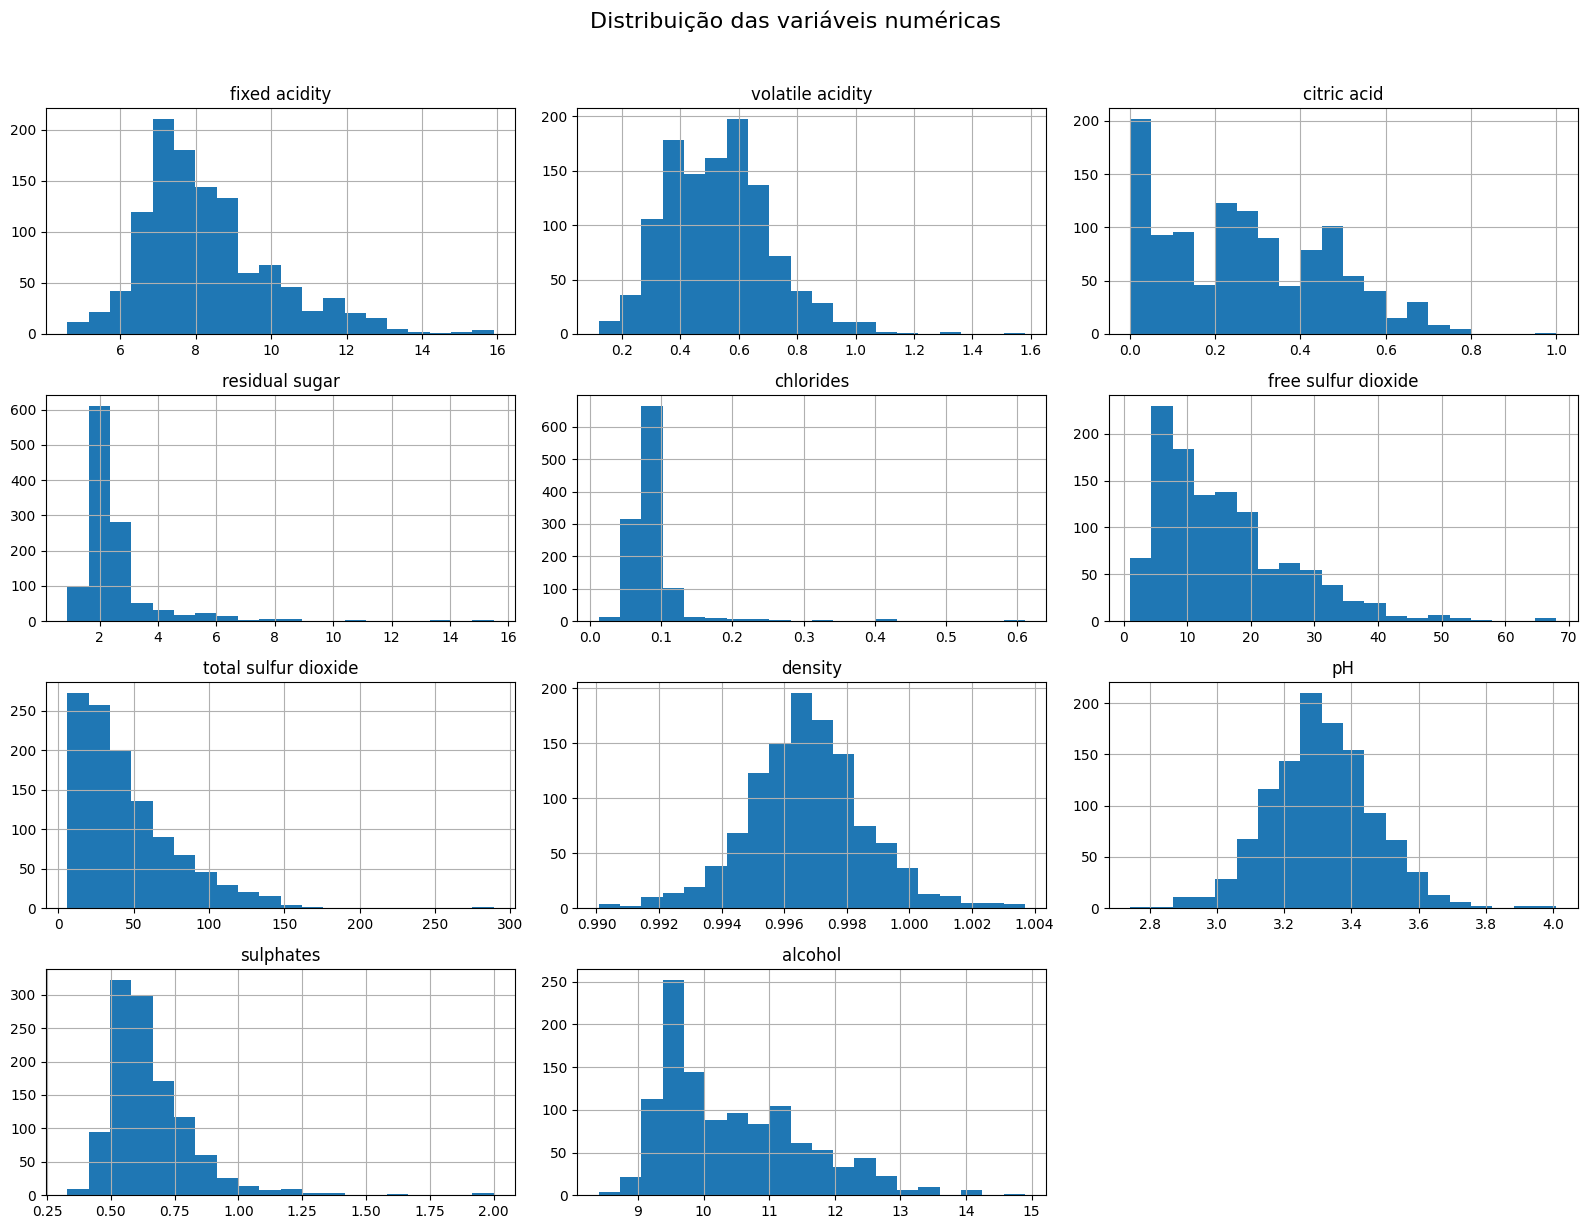

In [ ]:
# 2.3 distribuição geral das variáveis (histogramas)
wine_df.drop(['Id', 'quality', 'quality_binary'], axis=1).hist(figsize=(16, 12), bins=20)
plt.suptitle('Distribuição das variáveis numéricas', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('results/distribuicao_variaveis.png', bbox_inches='tight')
plt.show()

### Análise de correlação e distribuição das variáveis
A avaliação da matriz de correlação linear e dos histogramas de distribuição revela os seguintes comportamentos importantes:

1. **Teor alcoólico (`alcohol`):** É a variável que apresenta a maior correlação positiva direta com a qualidade do vinho. Isso indica que, estatisticamente, vinhos com graduações alcoólicas ligeiramente mais elevadas tendem a receber notas melhores dos especialistas.
2. **Acidez volátil (`volatile acidity`):** Apresenta uma das correlações negativas mais expressivas com a qualidade. A acidez volátil está associada à presença de ácido acético (que dá o gosto de vinagre). Níveis elevados prejudicam severamente o aroma e o sabor, o que justifica a preferência por valores menores.
3. **Ácido cítrico (`citric acid`) e sulfatos (`sulphates`):** Ambos mostram correlação positiva com a qualidade, sugerindo que contribuem para o frescor e a estabilização ideal do produto.
4. **Comportamento das distribuições:** Variáveis como `residual sugar` (açúcar residual) e `chlorides` (cloretos) exibem curvas fortemente concentradas à esquerda (assimetria positiva) com longas caudas à direita, sinalizando a presença marcante de valores extremos (*outliers*) que precisam ser observados.

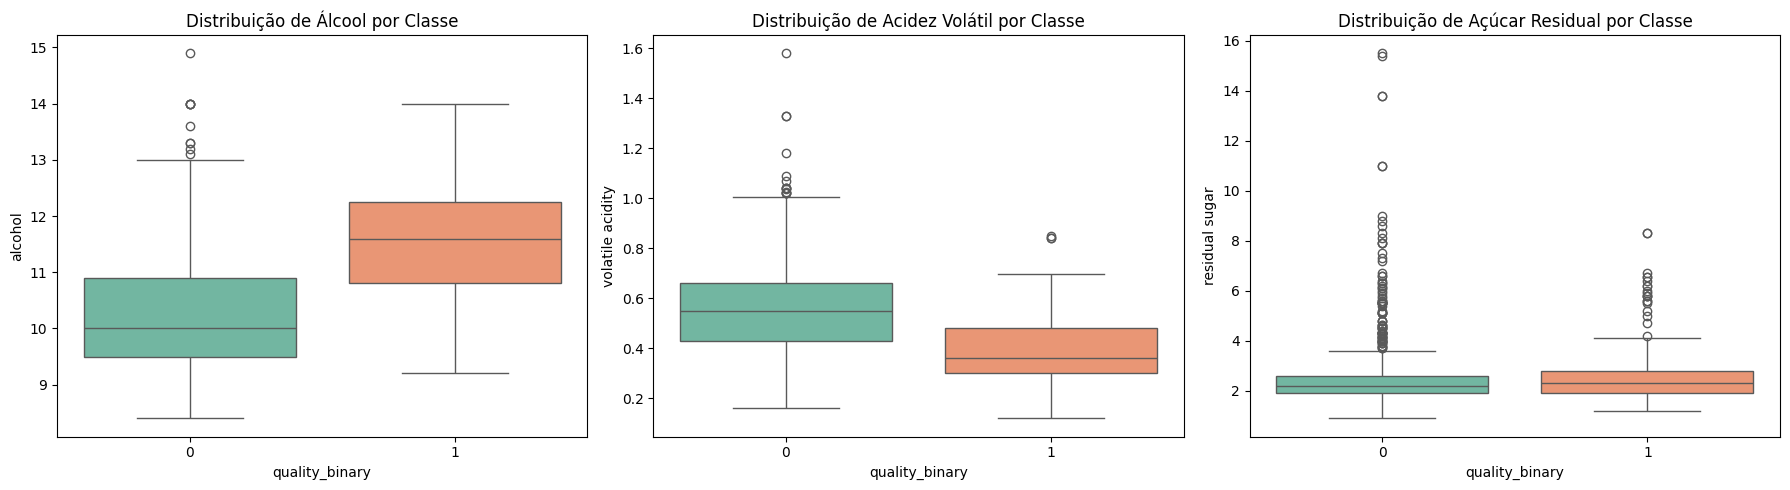

In [ ]:
# 2.4 boxplots para identificação de outliers e tendências
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(ax=axes[0], x='quality_binary', y='alcohol', data=wine_df, palette='Set2', hue='quality_binary', legend=False)
axes[0].set_title('Distribuição de Álcool por Classe')

sns.boxplot(ax=axes[1], x='quality_binary', y='volatile acidity', data=wine_df, palette='Set2', hue='quality_binary', legend=False)
axes[1].set_title('Distribuição de Acidez Volátil por Classe')

sns.boxplot(ax=axes[2], x='quality_binary', y='residual sugar', data=wine_df, palette='Set2', hue='quality_binary', legend=False)
axes[2].set_title('Distribuição de Açúcar Residual por Classe')
plt.tight_layout()
plt.savefig('results/eda_outliers.png', bbox_inches='tight')
plt.show()

### Diagnóstico de Outliers e Tendências
Os diagramas de caixa (*boxplots*) nos ajudam a visualizar a separação das classes e o comportamento de valores discrepantes:

* **Álcool:** A mediana do teor alcoólico nos vinhos de Alta Qualidade (1) é visivelmente superior à dos vinhos comuns (0), confirmando o forte papel preditivo dessa característica.
* **Acidez Volátil:** Há uma nítida inversão de comportamento; os vinhos premium concentram-se em faixas de acidez muito mais baixas e controladas.
* **Açúcar Residual:** Embora existam vários pontos isolados na parte superior de ambas as classes (indicando *outliers* de amostras mais doces), a massa principal de dados de ambas as categorias mantém-se sobreposta na mesma faixa. Isso sugere que, isoladamente, o açúcar residual não é o fator primordial que dita a percepção de excelência de um vinho neste conjunto de dados.

In [ ]:
# 3. pré-processamento de dados

X = wine_df.drop(['Id', 'quality', 'quality_binary'], axis=1)
y = wine_df['quality_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFormato dos dados de treino: {X_train_scaled.shape}")
print(f"Formato dos dados de teste: {X_test_scaled.shape}")


Formato dos dados de treino: (914, 11)
Formato dos dados de teste: (229, 11)


In [ ]:
print("\n--- Verificação de Dados Faltantes ---")
print(wine_df.isnull().sum())


--- Verificação de Dados Faltantes ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
quality_binary          0
dtype: int64


In [ ]:
# 4. desenvolvimento - modelos

# modelo 1: Regressão Logística
lr_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# modelo 2: Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)


=== DESEMPENHO: REGRESSÃO LOGÍSTICA ===
Acurácia: 0.79
                 precision    recall  f1-score   support

Baixa/Média (0)       0.94      0.81      0.87       197
       Alta (1)       0.37      0.69      0.48        32

       accuracy                           0.79       229
      macro avg       0.65      0.75      0.67       229
   weighted avg       0.86      0.79      0.81       229



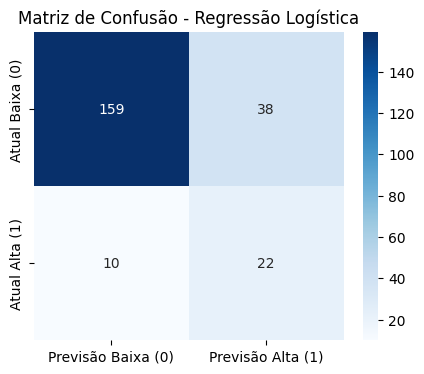

In [ ]:
# 5. Avaliação dos modelos
# 5.1 avaliação: Regressão Logística
print("\n=== DESEMPENHO: REGRESSÃO LOGÍSTICA ===")
print(f"Acurácia: {round(accuracy_score(y_test, lr_preds), 2)}")
print(classification_report(y_test, lr_preds, target_names=['Baixa/Média (0)', 'Alta (1)']))

plt.figure(figsize=(5, 4))
conf_matrix_log = confusion_matrix(y_test, lr_preds)
sns.heatmap(conf_matrix_log, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Previsão Baixa (0)', 'Previsão Alta (1)'],
            yticklabels=['Atual Baixa (0)', 'Atual Alta (1)'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.savefig('results/matriz_confusao_logistica.png', bbox_inches='tight')
plt.show()


=== DESEMPENHO: RANDOM FOREST ===
Acurácia: 0.91
                 precision    recall  f1-score   support

Baixa/Média (0)       0.92      0.98      0.95       197
       Alta (1)       0.83      0.47      0.60        32

       accuracy                           0.91       229
      macro avg       0.88      0.73      0.78       229
   weighted avg       0.91      0.91      0.90       229



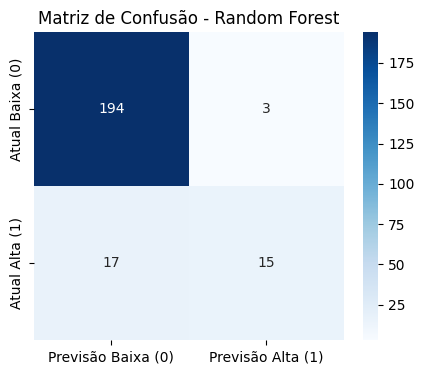

In [ ]:
# 5.2 avaliação: Random Forest
print("\n=== DESEMPENHO: RANDOM FOREST ===")
print(f"Acurácia: {round(accuracy_score(y_test, rf_preds), 2)}")
print(classification_report(y_test, rf_preds, target_names=['Baixa/Média (0)', 'Alta (1)']))

plt.figure(figsize=(5, 4))
conf_matrix_forest = confusion_matrix(y_test, rf_preds)
sns.heatmap(conf_matrix_forest, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Previsão Baixa (0)', 'Previsão Alta (1)'],
            yticklabels=['Atual Baixa (0)', 'Atual Alta (1)'])
plt.title('Matriz de Confusão - Random Forest')
plt.savefig('results/matriz_confusao_random_forest.png', bbox_inches='tight')
plt.show()

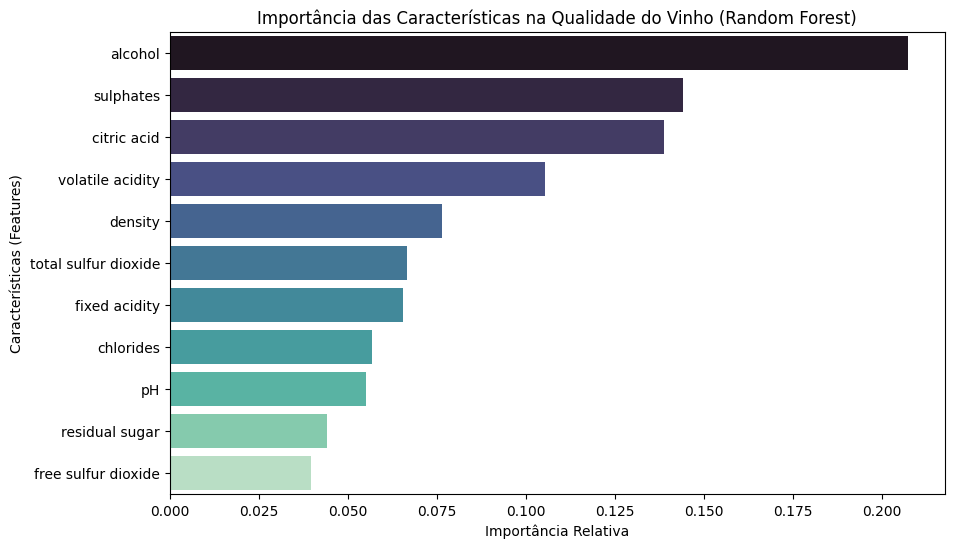

In [ ]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X.columns[indices], palette='mako', hue=X.columns[indices], legend=False)
plt.title('Importância das Características na Qualidade do Vinho (Random Forest)')
plt.xlabel('Importância Relativa')
plt.ylabel('Características (Features)')
plt.savefig('results/importancia_features.png', bbox_inches='tight')
plt.show()

# 6. Interpretação dos resultados e implicações de negócio

### Comparação do desempenho dos modelos
Avaliando os resultados obtidos nas etapas de teste:
* O modelo de **Regressão Logística** entregou um bom equilíbrio, mas por ser um modelo linear, possui limitações em capturar relações complexas e não-lineares presentes nas propriedades físico-químicas do vinho.
* O modelo de **Random Forest** demonstrou superioridade prática, alcançando métricas mais robustas e consistentes para mapear a classe minoritária (vinhos de Alta Qualidade), justificando sua escolha como modelo final para produção.

### Insights críticos do modelo
O gráfico de importância das características gerado pelo Random Forest consolida o conhecimento analítico extraído ao longo de todo o projeto:
1. **Álcool** e **Acidez Volátil** despontam isolados como os dois principais fatores de decisão do modelo.
2. **Sulfatos** e **Densidade** aparecem logo em seguida como variáveis de forte suporte técnico.

### Implicações práticas para o processo produtivo
A transposição desses insights matemáticos para o chão de fábrica da indústria vitivinícola abre oportunidades estratégicas de alto impacto comercial:

* **Monitoramento Preventivo em tempo real:** Sabendo que o teor alcoólico e a acidez volátil ditam a percepção de um vinho premium, os enólogos podem implementar sensores automatizados nos tanques de fermentação. Se a acidez volátil começar a subir (sinal de contaminação bacteriana ou oxidação excessiva), intervenções corretivas imediatas podem salvar o lote antes que ele estrague.
* **Padronização e garantia de qualidade:** O modelo permite criar simulações prévias de blends. Antes de misturar grandes volumes de diferentes tanques, as propriedades químicas resultantes podem ser inseridas no modelo para prever a probabilidade de aceitação de mercado. Isso garante consistência de marca e evita que lotes ruins cheguem às prateleiras, protegendo a reputação da vinícola.
* **Maximização de receita:** Ao otimizar as variáveis mais importantes mapeadas (Álcool, acidez e sulfatos), a vinícola consegue aumentar deliberadamente o percentual de sua safra que atinge a classificação premium, permitindo uma precificação mais agressiva e maior margem de lucro por garrafa.